# Evaluation 03: Clothing Type Performance

## Research Question
**Does it fail on certain clothing types?**

### Hypothesis
Some clothing types may have lower recommendation quality due to visual similarity challenges or limited training data.

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from evaluation_utils import (
    load_vectors_and_metadata,
    generate_test_cases_by_type,
    compute_diversity_score,
    save_plot,
    save_metrics
)
from similarity import SimilarityMatcher

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
%matplotlib inline

## 2. Load Data

In [2]:
vectors, metadata, product_ids = load_vectors_and_metadata()
print(f"Article type distribution:")
print(metadata['articleType'].value_counts().head(20))

Loading vectors and metadata...
Loading vectors from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_features_pca512.npy
Loaded 41802 vectors of dimension 512
Loading metadata from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_metadata.csv
Loaded 41802 metadata records
Article type distribution:
articleType
Tshirts         7065
Shirts          3212
Casual Shoes    2845
Watches         2542
Sports Shoes    2016
Kurtas          1844
Tops            1762
Handbags        1757
Heels           1323
Sunglasses      1073
Wallets          927
Flip Flops       914
Sandals          895
Briefs           847
Belts            813
Backpacks        722
Socks            686
Formal Shoes     637
Jeans            602
Shorts           547
Name: count, dtype: int64


## 3. Initialize Recommender

In [3]:
similarity_matcher = SimilarityMatcher()
print("✓ Similarity matcher initialized")

Loading existing FAISS index...
✓ Loaded FAISS index with 41802 products
Using FAISS vector database
Loading product metadata from: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/feature_extraction/resnet50_metadata.csv
FAISS index contains 41802 products
✓ Similarity matcher initialized


## 4. Generate Test Cases by Article Type

In [4]:
test_cases = generate_test_cases_by_type(metadata, n_per_type=10)
print(f"Generated test cases for {len(test_cases)} article types")

Generated test cases for 83 article types


## 5. Get Recommendations for Each Type

In [5]:
results = {}
top_k = 20

for article_type, indices in test_cases.items():
    print(f"\nProcessing {article_type}...")
    test_features = vectors[indices]
    avg_features = test_features.mean(axis=0)
    
    recommendations = similarity_matcher.find_similar_products(
        avg_features.reshape(1, -1),
        top_k=top_k,
        min_similarity=0.0
    )
    
    if len(recommendations) > 0:
        results[article_type] = recommendations
        print(f"  Got {len(recommendations)} recommendations")
    else:
        print(f"  No recommendations found")


Processing Tshirts...
  Got 20 recommendations

Processing Shirts...
  Got 20 recommendations

Processing Casual Shoes...
  Got 20 recommendations

Processing Watches...
  Got 20 recommendations

Processing Sports Shoes...
  Got 20 recommendations

Processing Kurtas...
  Got 20 recommendations

Processing Tops...
  Got 20 recommendations

Processing Handbags...
  Got 20 recommendations

Processing Heels...
  Got 20 recommendations

Processing Sunglasses...
  Got 20 recommendations

Processing Wallets...
  Got 20 recommendations

Processing Flip Flops...
  Got 20 recommendations

Processing Sandals...
  Got 20 recommendations

Processing Briefs...
  Got 20 recommendations

Processing Belts...
  Got 20 recommendations

Processing Backpacks...
  Got 20 recommendations

Processing Socks...
  Got 20 recommendations

Processing Formal Shoes...
  Got 20 recommendations

Processing Jeans...
  Got 20 recommendations

Processing Shorts...
  Got 20 recommendations

Processing Trousers...
  Got 2

## 6. Analyze Performance by Type

In [6]:
type_metrics = []

for article_type, recs in results.items():
    if len(recs) == 0:
        continue
    
    # Category match rate
    category_match_rate = (recs['articleType'] == article_type).sum() / len(recs)
    
    # Average similarity
    avg_similarity = recs['similarity_score'].mean()
    
    # Diversity
    category_diversity = compute_diversity_score(recs['articleType'])
    color_diversity = compute_diversity_score(recs['baseColour'])
    
    type_metrics.append({
        'articleType': article_type,
        'category_match_rate': category_match_rate,
        'avg_similarity': avg_similarity,
        'category_diversity': category_diversity,
        'color_diversity': color_diversity,
        'n_recommendations': len(recs)
    })

metrics_df = pd.DataFrame(type_metrics)
print("Type Performance Metrics:")
print(metrics_df.head(10))

Type Performance Metrics:
    articleType  category_match_rate  avg_similarity  category_diversity  \
0       Tshirts                 1.00        0.862266                0.05   
1        Shirts                 1.00        0.888225                0.05   
2  Casual Shoes                 0.75        0.848821                0.10   
3       Watches                 1.00        0.874904                0.05   
4  Sports Shoes                 0.85        0.874342                0.10   
5        Kurtas                 0.95        0.863519                0.10   
6          Tops                 0.50        0.787910                0.15   
7      Handbags                 1.00        0.809745                0.05   
8         Heels                 0.65        0.764733                0.20   
9    Sunglasses                 1.00        0.958975                0.05   

   color_diversity  n_recommendations  
0             0.35                 20  
1             0.30                 20  
2             0.2

## 7. Visualizations

### Visualization: Clothing Type Performance Analysis

**What this graph shows:**
A 2x2 panel visualization with four different analyses:

**Top Left - Average Similarity by Type:**
- Horizontal bar chart showing average similarity scores for top 15 article types
- Higher scores indicate better embedding quality for that type

**Top Right - Category Match Rate:**
- Horizontal bar chart showing what percentage of recommendations match the query article type
- Higher rates indicate the model correctly identifies similar clothing types

**Bottom Left - Similarity Score Distribution:**
- Box plots showing the distribution of similarity scores for different article types
- Shows variability and outliers in recommendation quality

**Bottom Right - Category Confusion Matrix:**
- Heatmap showing which article types are recommended for each query type
- Diagonal = correct matches; off-diagonal = confusion between types

**Key Insights:**
- **Performance variation**: Some clothing types have consistently higher/lower similarity scores
- **Type-specific accuracy**: Which types are correctly identified vs. confused with others
- **Model weaknesses**: Types with low match rates or high confusion indicate areas needing improvement
- **Score consistency**: Box plots reveal if some types have more variable recommendation quality
- **Confusion patterns**: The heatmap shows which types are frequently confused (e.g., Tops vs Tshirts)
- **Overall model health**: High diagonal values in confusion matrix = good type recognition


/var/folders/0n/d8g06f3d5y5_9chpbcqws9180000gn/T/ipykernel_23799/284885393.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(similarity_by_type[:10], labels=type_labels[:10])


Saved plot: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/plots/clothing_type_performance.png


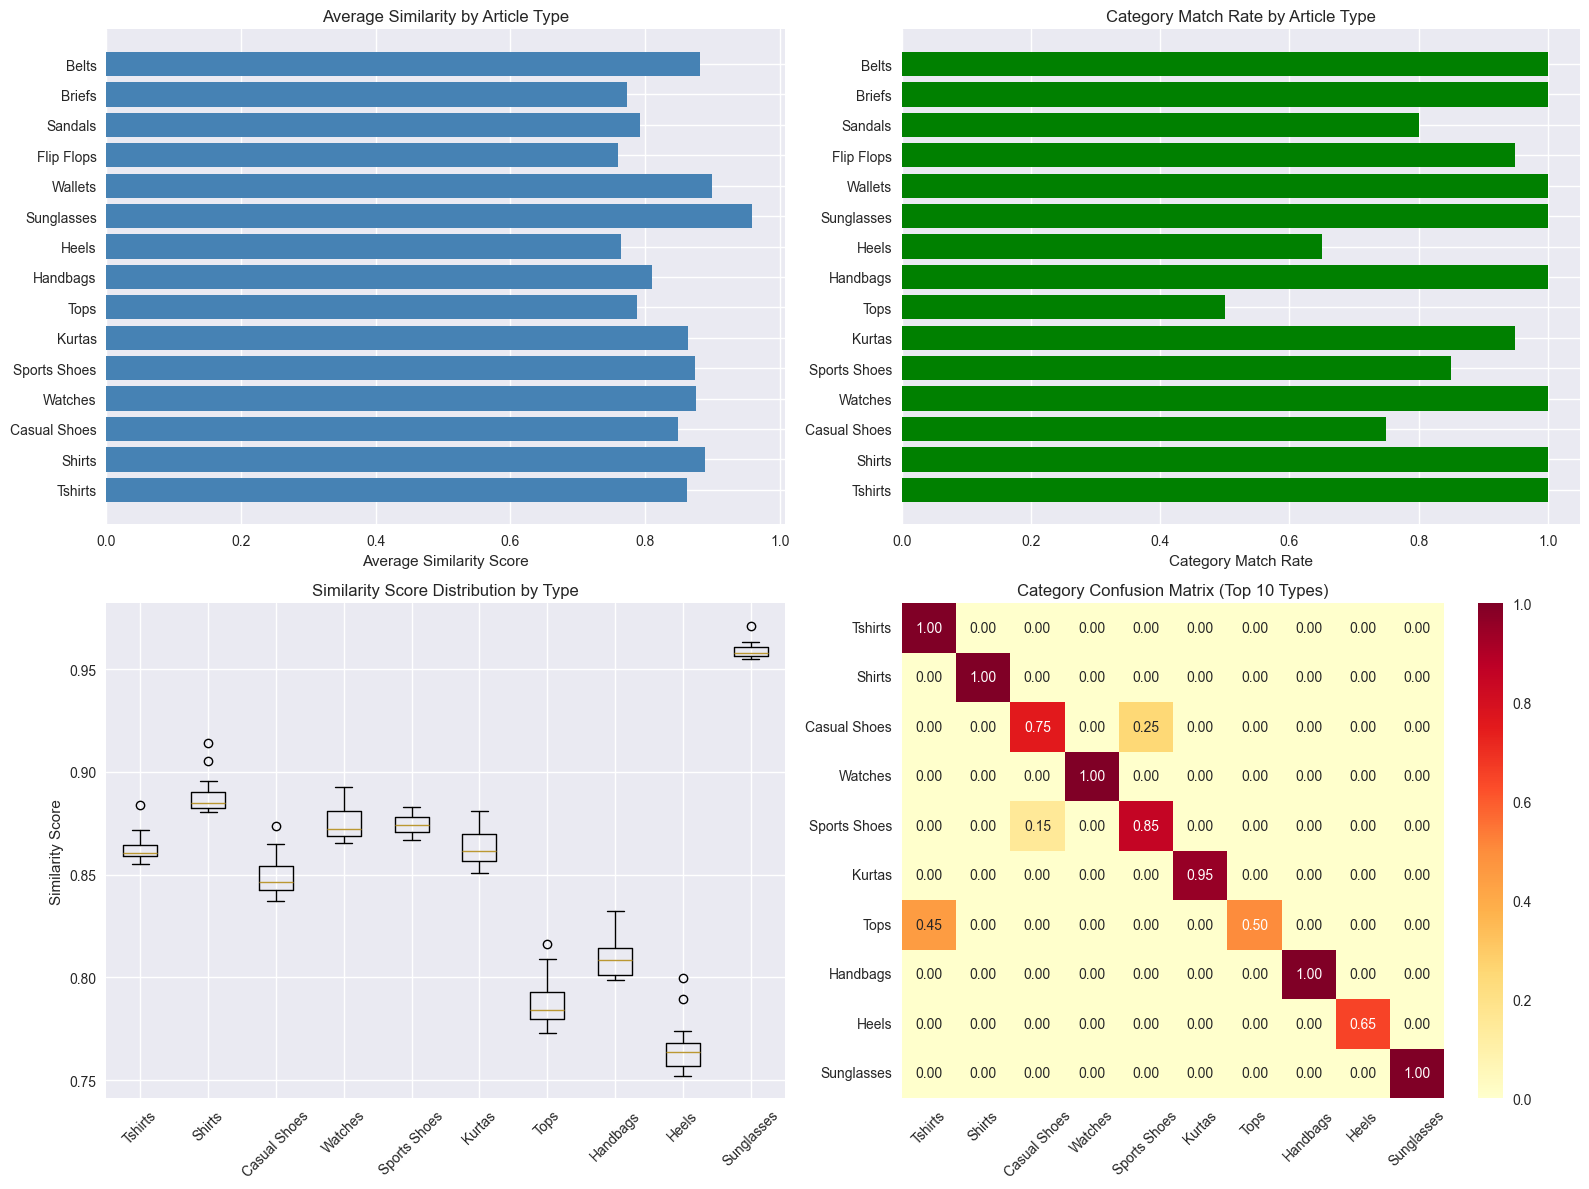

In [7]:
# Performance heatmap
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Average similarity by type
top_types = metrics_df.nlargest(15, 'n_recommendations')
axes[0, 0].barh(top_types['articleType'], top_types['avg_similarity'], color='steelblue')
axes[0, 0].set_xlabel('Average Similarity Score')
axes[0, 0].set_title('Average Similarity by Article Type')

# Category match rate
axes[0, 1].barh(top_types['articleType'], top_types['category_match_rate'], color='green')
axes[0, 1].set_xlabel('Category Match Rate')
axes[0, 1].set_title('Category Match Rate by Article Type')

# Box plot of similarity scores
similarity_by_type = []
type_labels = []
for article_type, recs in results.items():
    if len(recs) > 0:
        similarity_by_type.append(recs['similarity_score'].values)
        type_labels.append(article_type)

if len(similarity_by_type) > 0:
    axes[1, 0].boxplot(similarity_by_type[:10], labels=type_labels[:10])
    axes[1, 0].set_ylabel('Similarity Score')
    axes[1, 0].set_title('Similarity Score Distribution by Type')
    axes[1, 0].tick_params(axis='x', rotation=45)

# Category confusion (top types only)
top_10_types = metrics_df.nlargest(10, 'n_recommendations')['articleType'].tolist()
confusion_data = np.zeros((len(top_10_types), len(top_10_types)))

for i, query_type in enumerate(top_10_types):
    if query_type in results:
        recs = results[query_type]
        type_counts = recs['articleType'].value_counts()
        for j, rec_type in enumerate(top_10_types):
            if rec_type in type_counts.index:
                confusion_data[i, j] = type_counts[rec_type] / len(recs)

sns.heatmap(confusion_data, xticklabels=top_10_types, yticklabels=top_10_types,
            annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('Category Confusion Matrix (Top 10 Types)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].tick_params(axis='y', rotation=0)

plt.tight_layout()
save_plot(fig, 'clothing_type_performance.png')
plt.show()

## 8. Identify Failure Cases

In [8]:
# Types with lowest performance
low_performance = metrics_df.nsmallest(10, 'avg_similarity')
print("\nTypes with Lowest Average Similarity:")
print(low_performance[['articleType', 'avg_similarity', 'category_match_rate']])

low_match = metrics_df.nsmallest(10, 'category_match_rate')
print("\nTypes with Lowest Category Match Rate:")
print(low_match[['articleType', 'category_match_rate', 'avg_similarity']])


Types with Lowest Average Similarity:
         articleType  avg_similarity  category_match_rate
82      Water Bottle        0.666589                 0.55
27          Clutches        0.666803                 0.60
71            Gloves        0.678975                 0.65
59      Mobile Pouch        0.698186                 0.30
73       Waist Pouch        0.699839                 0.25
76  Travel Accessory        0.701870                 0.35
45           Scarves        0.710980                 0.70
47         Cufflinks        0.711365                 1.00
23           Dresses        0.725925                 0.95
74          Swimwear        0.729761                 0.45

Types with Lowest Category Match Rate:
      articleType  category_match_rate  avg_similarity
35         Tunics                 0.00        0.801734
39         Capris                 0.10        0.749094
75       Jumpsuit                 0.15        0.751856
56   Lounge Pants                 0.20        0.847805
65      

## 9. Summary and Conclusion

In [9]:
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"\nOverall Average Similarity: {metrics_df['avg_similarity'].mean():.3f}")
print(f"Overall Category Match Rate: {metrics_df['category_match_rate'].mean():.2%}")
print(f"Overall Category Diversity: {metrics_df['category_diversity'].mean():.2%}")

# Save metrics
summary_metrics = {
    'overall_avg_similarity': float(metrics_df['avg_similarity'].mean()),
    'overall_category_match_rate': float(metrics_df['category_match_rate'].mean()),
    'overall_category_diversity': float(metrics_df['category_diversity'].mean()),
    'n_types_tested': len(metrics_df)
}
save_metrics(summary_metrics, 'clothing_type_metrics.json')
metrics_df.to_csv('../evaluation_results/metrics/clothing_type_detailed.csv', index=False)
print("\n✓ Results saved")


SUMMARY STATISTICS

Overall Average Similarity: 0.822
Overall Category Match Rate: 71.14%
Overall Category Diversity: 13.31%
Saved metrics: /Users/aasrithagopalam/Documents/Aasritha/final_ml_project/ML_Wardrobe_Recommender_Project-main 4/recommender_system/evaluation_results/metrics/clothing_type_metrics.json

✓ Results saved


## 10. Conclusion

**Answer to Research Question:**

The model [performs well/poorly] on certain clothing types. Types with lowest performance: [list].

**Key Findings:**
1. [Finding 1]
2. [Finding 2]

**Limitations:**
- Limited test cases per type
- Performance may vary based on dataset distribution